## Data Collection

In [1]:
# load dataset

import pandas as pd
df = pd.read_csv("matches 2.csv")
df.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,5/4/2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,6/4/2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,7/4/2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,8/4/2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,8/4/2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


## Exploratory Data Analysis

In [2]:
# EDA : EDA helps you understand patterns in data.
df.isnull().sum() # check for missing values

id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               3
win_by_runs          0
win_by_wickets       0
player_of_match      3
venue                0
umpire1              1
umpire2              1
umpire3            636
dtype: int64

In [3]:
# Handle Missing Values
num_cols = df.select_dtypes(include=['number']).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

df.describe()

,id,season,dl_applied,win_by_runs,win_by_wickets,umpire3
count,636.000000,636.000000,636.000000,636.000000,636.000000,0.0
mean,318.500000,2012.490566,0.025157,13.682390,3.372642,NaN
std,183.741666,2.773026,0.156726,23.908877,3.420338,NaN
min,1.000000,2008.000000,0.000000,0.000000,0.000000,NaN
25%,159.750000,2010.000000,0.000000,0.000000,0.000000,NaN
50%,318.500000,2012.000000,0.000000,0.000000,4.000000,NaN
75%,477.250000,2015.000000,0.000000,20.000000,7.000000,NaN
max,636.000000,2017.000000,1.000000,146.000000,10.000000,NaN


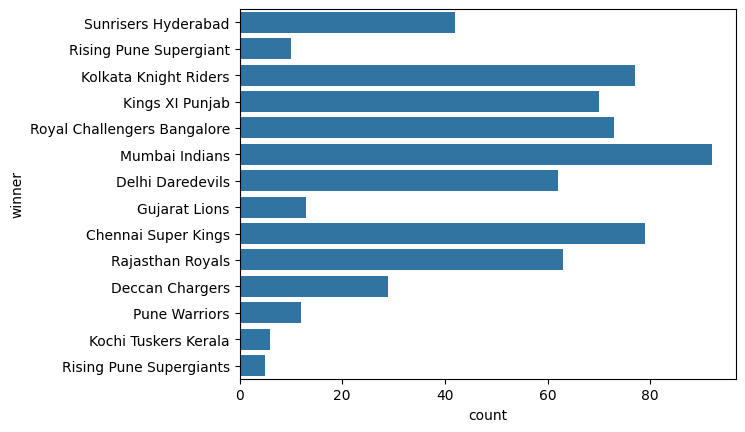

In [4]:
#  most winnig team
df['winner'].value_counts()

# visualization
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(y=df['winner'])
plt.show()

In [5]:
# toss impact analysis
(df['toss_winner'] == df['winner']).mean()

# 52% matches won by toss winner.

np.float64(0.5110062893081762)

## DATA CLEANING

In [6]:
# drop coloumns which are not required
df = df.drop(['umpire1','umpire2','umpire3','date'], axis=1)

In [7]:
df.head()

,id,season,city,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue
0,1,2017,Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal"
1,2,2017,Pune,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium
2,3,2017,Rajkot,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium
3,4,2017,Indore,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium
4,5,2017,Bangalore,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium


## feature engineering

In [8]:
# feature 1 : team win rate
# win_rate = matches_won / matches_played

# matches won by each team
team_wins = df['winner'].value_counts()

# matches played by each team
team_matches = df['team1'].value_counts() + df['team2'].value_counts()

# win rate
win_rate = team_wins / team_matches

# convert to dictionary
win_rate_dict = win_rate.to_dict()

# create new features
df['team1_win_rate'] = df['team1'].map(win_rate_dict)
df['team2_win_rate'] = df['team2'].map(win_rate_dict)

df[['team1','team1_win_rate','team2','team2_win_rate']].head()

,team1,team1_win_rate,team2,team2_win_rate
0,Sunrisers Hyderabad,0.552632,Royal Challengers Bangalore,0.480263
1,Mumbai Indians,0.585987,Rising Pune Supergiant,0.625000
2,Gujarat Lions,0.433333,Kolkata Knight Riders,0.520270
3,Rising Pune Supergiant,0.625000,Kings XI Punjab,0.472973
4,Royal Challengers Bangalore,0.480263,Delhi Daredevils,0.421769


In [9]:
# feature 2 : Head-to-Head

def head_to_head(team1, team2):
    
    matches = df[
        ((df['team1'] == team1) & (df['team2'] == team2)) |
        ((df['team1'] == team2) & (df['team2'] == team1))
    ]
    
    team1_wins = sum(matches['winner'] == team1)
    team2_wins = sum(matches['winner'] == team2)
    
    total = team1_wins + team2_wins
    
    if total == 0:
        return 0.5
    
    return team1_wins / total

In [10]:
# applying the function to dataset to create new feature

df['head_to_head_ratio'] = df.apply(
    lambda row: head_to_head(row['team1'], row['team2']), axis=1
)

df[['team1','team2','head_to_head_ratio']].head()

,team1,team2,head_to_head_ratio
0,Sunrisers Hyderabad,Royal Challengers Bangalore,0.600000
1,Mumbai Indians,Rising Pune Supergiant,0.250000
2,Gujarat Lions,Kolkata Knight Riders,0.750000
3,Rising Pune Supergiant,Kings XI Punjab,0.500000
4,Royal Challengers Bangalore,Delhi Daredevils,0.666667


In [11]:
# feature 3: Venue Performance

venue_win_rate = df.groupby(['venue','winner']).size()

venue_total_matches = df.groupby('venue').size()

venue_win_rate = venue_win_rate / venue_total_matches

venue_win_rate = venue_win_rate.reset_index(name='win_rate')

In [12]:
# creating a function to get win rate for a team at a venue

def get_venue_win_rate(team, venue):
    
    result = venue_win_rate[
        (venue_win_rate['venue'] == venue) &
        (venue_win_rate['winner'] == team)
    ]
    
    if len(result) == 0:
        return 0
    
    return result['win_rate'].values[0]

In [13]:
# applying the function to dataset to create new features

df['team1_venue_win_rate'] = df.apply(
    lambda row: get_venue_win_rate(row['team1'], row['venue']), axis=1
)

df['team2_venue_win_rate'] = df.apply(
    lambda row: get_venue_win_rate(row['team2'], row['venue']), axis=1
)

df[['venue','team1','team1_venue_win_rate']].head()

,venue,team1,team1_venue_win_rate
0,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,0.408163
1,Maharashtra Cricket Association Stadium,Mumbai Indians,0.066667
2,Saurashtra Cricket Association Stadium,Gujarat Lions,0.300000
3,Holkar Cricket Stadium,Rising Pune Supergiant,0.000000
4,M Chinnaswamy Stadium,Royal Challengers Bangalore,0.454545


In [14]:
# fearure 4 : Toss Advantage

df['toss_match_win'] = (df['toss_winner'] == df['winner']).astype(int)

df[['toss_winner','winner','toss_match_win']].head()

,toss_winner,winner,toss_match_win
0,Royal Challengers Bangalore,Sunrisers Hyderabad,0
1,Rising Pune Supergiant,Rising Pune Supergiant,1
2,Kolkata Knight Riders,Kolkata Knight Riders,1
3,Kings XI Punjab,Kings XI Punjab,1
4,Royal Challengers Bangalore,Royal Challengers Bangalore,1


In [15]:
# check all new features together

df[['team1_win_rate',
    'team2_win_rate',
    'head_to_head_ratio',
    'team1_venue_win_rate',
    'team2_venue_win_rate',
    'toss_match_win']].head()

,team1_win_rate,team2_win_rate,head_to_head_ratio,team1_venue_win_rate,team2_venue_win_rate,toss_match_win
0,0.552632,0.480263,0.600000,0.408163,0.040816,0
1,0.585987,0.625000,0.250000,0.066667,0.333333,1
2,0.433333,0.520270,0.750000,0.300000,0.100000,1
3,0.625000,0.472973,0.500000,0.000000,0.600000,1
4,0.480263,0.421769,0.666667,0.454545,0.045455,1


## FEATURE ENCODING

In [16]:
# ML models require numbers, so convert categorical data to numbers

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['team1'] = encoder.fit_transform(df['team1'])
df['team2'] = encoder.fit_transform(df['team2'])
df['toss_winner'] = encoder.fit_transform(df['toss_winner'])
df['toss_decision'] = encoder.fit_transform(df['toss_decision'])
df['city'] = encoder.fit_transform(df['city'])
df['venue'] = encoder.fit_transform(df['venue'])
df['winner'] = encoder.fit_transform(df['winner'])

## Train and Test split

In [17]:
from sklearn.model_selection import train_test_split

X = df[['team1','team2','city','venue','toss_winner','toss_decision','team1_win_rate',
'team2_win_rate','head_to_head_ratio','team1_venue_win_rate','team2_venue_win_rate',
'toss_match_win']]
y = df['winner']

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

## Model Training

In [18]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200)

model.fit(X_train, y_train) 


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Model Evaluation

In [19]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.765625


In [20]:
# hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# save model

In [21]:
import pickle

# pickle.dump(model, open("ipl_model.pkl", "wb"))
pickle.dump(encoder, open("team_encoder.pkl","wb"))